# Deep Agents Overview

- deepagents is a standalone library for building agents that can tackle complex, multi-step tasks. 
- It is built on langGraph and inspired by Claude Code, Deep Research, Manus.
- It comes with planning capbilities, file systems for context management and ability to spawn subagents

Components
- Planning
- Subagents
- System Prompt
- File system 


When to use 
- handle complex, multistep tasks that requires planning and decomposition 
- Manage large amt of context through file system tools
- Delegate work to specialized sub agents for context isolation 
- Persist memeory across conversation and threadsa 


In [2]:
# Basic Deep Agents
import os
from dotenv import load_dotenv
load_dotenv()

os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')
os.environ['TAVILYA_API_KEY'] = os.getenv('TAVILY_API_KEY')

In [23]:
# Tools - Internet search

from tavily import TavilyClient
from typing import Literal

tavily_client = TavilyClient(api_key=os.getenv('TAVILY_API_KEY'))

def web_search(query: str, max_results:int=5, topic: Literal['sports', 'news', 'financial']='general', include_raw_content: bool=False) -> str:
    """Run a web search"""
    return tavily_client.search(query, max_results=max_results, include_raw_content=include_raw_content, topic=topic)

In [25]:
result = web_search('what are robots?')

In [26]:
result

{'query': 'what are robots?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://builtin.com/robotics',
   'title': 'Robotics: What Are Robots? | Built In',
   'content': '# Robotics: What Are Robots? Robotics is the use of machines that can be programmed to perform tasks. And it’s boosting efficiency and safety in industries like manufacturing and healthcare. Robotics is an interdisciplinary sector of science and engineering dedicated to the design, construction and use of mechanical robots. ## What Is Robotics? Robotics is the intersection of science, engineering and technology that produces machines, called robots, that replicate or substitute for human actions. Robots perform basic and repetitive tasks with greater efficiency and accuracy than humans, making them ideal for industries like manufacturing. However, the introduction of artificial intelligence in robotics has given robots the ability to handle increasingly complex situations in v

In [27]:
from langchain.chat_models import init_chat_model
model = init_chat_model('groq:llama-3.3-70b-versatile')
model

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002423A5223F0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002423A5238C0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

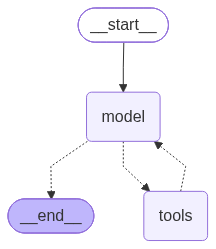

In [28]:
# basic agent
from langchain.agents import create_agent  

simple_agent = create_agent(
    model=model,
    tools=[web_search]
)
simple_agent

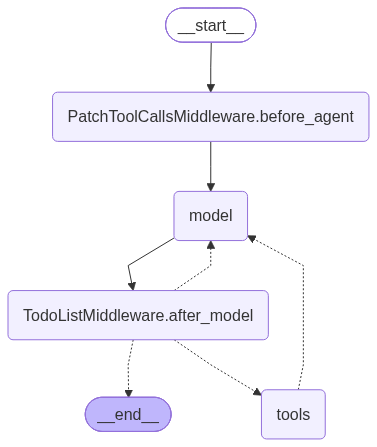

In [31]:
# create a deep agent
from deepagents import create_deep_agent

# prompt

# agents
deepagent = create_deep_agent(
    model=model,
    tools=[web_search],
    system_prompt='Act as a researcher'
)
deepagent


In [32]:
result = deepagent.invoke({'messages':[{'role':'user', 'content':'what is deepagents?'}]})
result

{'messages': [HumanMessage(content='what is deepagents?', additional_kwargs={}, response_metadata={}, id='50037650-2e9f-438e-9ab3-700fff1a8cdc'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '6d3d7aqqm', 'function': {'arguments': '{"max_results":5,"query":"deepagents"}', 'name': 'web_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 9223, 'total_tokens': 9245, 'completion_time': 0.082998272, 'completion_tokens_details': None, 'prompt_time': 0.649329147, 'prompt_tokens_details': None, 'queue_time': 0.057308743, 'total_time': 0.732327419}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f7eca-8aac-7723-b9c2-1982b2fdf3ff-0', tool_calls=[{'name': 'web_search', 'args': {'max_results': 5, 'query': 'deepagents'}, 'id': '6d3d7aqqm', 'type': 'tool_call'}], invalid_to

In [33]:
result['messages'][-1].content

"Deepagents is an open-source agent harness that provides a pre-built coding agent in your terminal, similar to Claude Code or Cursor, powered by any LLM. It is built on top of LangChain's `create_agent` and provides a more opinionated harness with filesystem, sub-agents, context management, and skills bundled in. Deep Agents is designed for production agent deployments and can be used when you want the full harness — planning, context management, delegation — out of the box. It is available as an SDK and CLI, and can be used in your codebase or run directly in your terminal."

In [34]:
result['files']

{}